<a href="https://colab.research.google.com/github/abdulwasaeee/modern-computer-vision-course/blob/main/GANs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![](https://github.com/rajeevratan84/ModernComputerVision/raw/main/logo_MCV_W.png)

# **Generative Adversarial Networks (GANs) in PyTorch - Deep Convolutional GANs or DCGAN with MNIST**

---

In this lesson, we will learn how to use PyTorch to create a simple DCGAN using the MNIST dataset.

## **1. Setting up our data and modules**

In [1]:
import torch
from torch import nn

import math
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
torch.manual_seed(42)

cuda


## **2. Fetch our MNIST Dataset using torchvision and Create our transforms and Data Loader**

In [2]:
batch_size = 32

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

train_set = torchvision.datasets.MNIST(root=".", train=True, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.93MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.41MB/s]


### **Now let's plot some of our original (real) data**

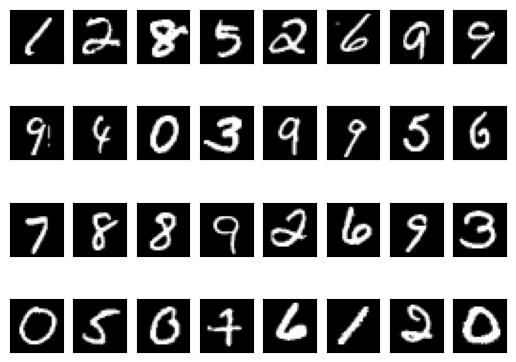

In [3]:
samples, labels = next(iter(train_loader))

for i in range(32):
    ax = plt.subplot(4, 8, i + 1)
    plt.imshow(samples[i].reshape(28, 28), cmap="gray")
    plt.xticks([])
    plt.yticks([])

(np.float64(-0.5), np.float64(91.5), np.float64(91.5), np.float64(-0.5))

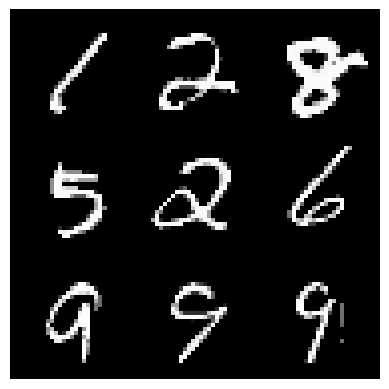

In [21]:
from torchvision.utils import make_grid
grid= make_grid(samples[:9],nrow=3)
plt.imshow(grid.permute(1,2,0))
plt.axis('off')

## **4. Define our Discriminator Model**

Our Descriminator receives the 28x28 image generated by our Generator and outputs a probability score of it belonging to the original dataset or not.

In [23]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # We don't use Conv layers here but we vectorize our inputs
            nn.Linear(784, 2048),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
      x = torch.flatten(x, start_dim=1)
      output = self.model(x)
      return output

# We instantiate our mode and send it to the GPU
discriminator = Discriminator().to(device=device)

## **5. Define our Generator Model**

In [25]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 784),
            nn.Tanh(), # We use the Tanh() activation fucntion so that our outputs lie between -1 and 1
        )

    def forward(self, x):
      output = self.model(x)
      output = output.reshape(x.size(0), 1, 28, 28)
      return output


# We instantiate our mode and send it to the GPU
generator = Generator().to(device=device)

## **Set our training parameters**

In [32]:
# Set our learning rate, epochs
lr = 0.0001
epochs = 20
lossfn = nn.BCELoss()

optimizerD = torch.optim.Adam(discriminator.parameters(), lr=lr)
optimizerG = torch.optim.Adam(generator.parameters(), lr=lr)

In [33]:
for epoch in range(epochs):
    for n, (samples, labels) in enumerate(train_loader):
        # Get data for training the discriminator
        realsamples = samples.to(device=device)
        reallabels = torch.ones((batch_size, 1)).to(device=device)
        latentsamples = torch.randn((batch_size, 100)).to(device=device)
        generatedsamples = generator(latentsamples)
        generatedlabels = torch.zeros((batch_size, 1)).to(device=device)
        allsamples = torch.cat((realsamples, generatedsamples))
        alllabels = torch.cat((reallabels, generatedlabels))

        # Training the discriminator
        discriminator.zero_grad()
        outputD1 = discriminator(allsamples)
        lossD = lossfn(outputD1, alllabels)
        lossD.backward()
        optimizerD.step()

        # Data for training the generator
        latentsamples = torch.randn((batch_size, 100)).to(device=device)

        # Training the generator
        generator.zero_grad()
        generatedsamples = generator(latentsamples)
        outputD2 = discriminator(generatedsamples)
        lossG = lossfn(outputD2, reallabels)
        lossG.backward()
        optimizerG.step()

        # Show loss
        if n == batch_size - 1:
            print(f"Epoch: {epoch} Descrimianted Loss: {lossD}")
            print(f"Epoch: {epoch} Generator Loss: {lossG}")

Epoch: 0 Descrimianted Loss: 4.68200504060932e-24
Epoch: 0 Generator Loss: 95.506591796875
Epoch: 1 Descrimianted Loss: 0.0
Epoch: 1 Generator Loss: 100.0
Epoch: 2 Descrimianted Loss: 0.0
Epoch: 2 Generator Loss: 98.125244140625
Epoch: 3 Descrimianted Loss: 1.940996753546642e-06
Epoch: 3 Generator Loss: 99.15572357177734
Epoch: 4 Descrimianted Loss: 1.3892904797792224e-29
Epoch: 4 Generator Loss: 94.4659194946289
Epoch: 5 Descrimianted Loss: 8.873979243215568e-38
Epoch: 5 Generator Loss: 97.5591049194336
Epoch: 6 Descrimianted Loss: 5.619297085563619e-38
Epoch: 6 Generator Loss: 99.5986099243164
Epoch: 7 Descrimianted Loss: 4.429591599768995e-35
Epoch: 7 Generator Loss: 99.13255310058594
Epoch: 8 Descrimianted Loss: 0.0
Epoch: 8 Generator Loss: 100.0
Epoch: 9 Descrimianted Loss: 0.0
Epoch: 9 Generator Loss: 99.59599304199219
Epoch: 10 Descrimianted Loss: 7.159472197529527e-28
Epoch: 10 Generator Loss: 93.72401428222656
Epoch: 11 Descrimianted Loss: 7.339580966594094e-41
Epoch: 11 Gener

## **5. Now let's Inspect our Generated Samples**

In [34]:
latentsamples = torch.randn(batch_size, 100).to(device=device)
generatedsamples = generator(latentsamples)

(np.float64(-0.5), np.float64(241.5), np.float64(121.5), np.float64(-0.5))

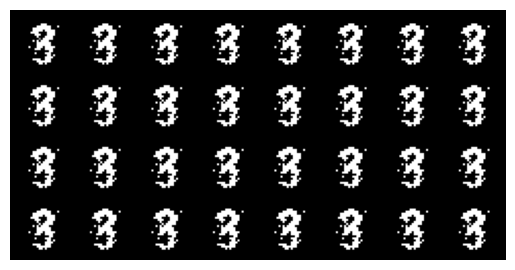

In [35]:
grid= make_grid(generatedsamples).cpu()
plt.imshow(grid.permute(1,2,0))
plt.axis('off')